# Livrable 2 - Classification d'Images par Réseaux de Neurones

### Groupe 2 — Projet Leyenda

## Présentation du Problème

L'entreprise souhaite automatiser la sélection de photos pour l'annotation. Ce livrable fournit un système de classification binaire (**Photo vs Non-Photo**) capable de filtrer automatiquement les images et de les trier dans le répertoire `data/processed/`.

### Dataset
| Catégorie | Description |
|---|---|
| **Photo** | Photographies réelles — **classe cible** |
| **Painting** | Peintures (dont certaines très réalistes → cas difficile) |
| **Schematics** | Schémas et diagrammes techniques |
| **Sketch** | Croquis et dessins en N&B |
| **Text** | Documents textuels scannés |

### Stratégie
1. **Modèle CNN de base** — référence rapide à entraîner from scratch
2. **MobileNetV2 (Transfer Learning)** — modèle principal, pré-entraîné sur ImageNet, fine-tuné sur nos données
3. **Tri automatique** — les images sont copiées dans `data/processed/Photo/` ou `data/processed/Not_Photo/`

> **Justification du choix de MobileNetV2** : les réseaux pré-entraînés sur ImageNet ont déjà appris à reconnaître les textures et structures visuelles génériques des photos réelles. Cette connaissance préalable est exactement ce dont on a besoin pour distinguer des photos de peintures ou de schémas. MobileNetV2 offre un excellent compromis vitesse / précision et est léger à fine-tuner.

---
## 1. Imports & Configuration

In [1]:
# Installation des dépendances
%pip install --upgrade tensorflow keras numpy pandas matplotlib scikit-learn seaborn -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import os
import random
import shutil
import json
import tensorflow as tf
import seaborn as sns
import warnings

from pathlib import Path
from tensorflow.keras import Sequential, layers, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D,
    RandomFlip, RandomRotation, RandomZoom, RandomContrast
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')

# Seed global pour reproducibilité
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU dispo   : {tf.config.list_physical_devices('GPU')}")

Note: you may need to restart the kernel to use updated packages.
TensorFlow  : 2.21.0
GPU dispo   : []


In [2]:
# ─────────────────────────────────────────────────────────────────
# CONFIGURATION CENTRALISÉE
# Tous les chemins et hyperparamètres sont ici
# ─────────────────────────────────────────────────────────────────
BASE_DIR      = Path('../')
DATA_RAW      = BASE_DIR / 'data' / 'raw'
DATA_PROC     = BASE_DIR / 'data' / 'processed'
MODELS_DIR    = BASE_DIR / 'src' / 'models'
FIGURES_DIR   = BASE_DIR / 'notebooks' / 'figures'

# Créer les dossiers de sortie
for d in [DATA_PROC / 'Photo', DATA_PROC / 'Not_Photo', MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Paramètres images
IMAGE_H    = 224   # MobileNetV2 attend 224×224 (standard ImageNet)
IMAGE_W    = 224
BATCH_SIZE = 32

# Paramètres entraînement
EPOCHS_CNN       = 30   # epochs max pour CNN from scratch
EPOCHS_TRANSFER  = 20   # epochs max pour MobileNetV2 (converge vite)
EPOCHS_FINETUNE  = 10   # epochs de fine-tuning (déverrouillage des dernières couches)

# Seuil de décision pour classification binaire
# > THRESHOLD → Photo, sinon Not_Photo
THRESHOLD  = 0.5

# Graine aléatoire pour reproducibilité
RANDOM_SEED = 42

print("📁 Chemins configurés :")
print(f"  raw      : {DATA_RAW}")
print(f"  processed: {DATA_PROC}")
print(f"  models   : {MODELS_DIR}")
print(f"\n📐 Dimensions des images: {IMAGE_H}×{IMAGE_W}")
print(f"📦 Taille des batches: {BATCH_SIZE}")
print(f"🔄 Nombre d'epochs: {EPOCHS_CNN}")

# Vérifier l'existence du dossier raw
if DATA_RAW.exists():
    print(f"✓ Répertoire trouvé: {DATA_RAW}")
    print(f"\n📂 Catégories détectées :")
    for folder in sorted(DATA_RAW.iterdir()):
        if folder.is_dir():
            n = len(list(folder.glob('*.*')))
            print(f"  - {folder.name:<15} : {n} images")
else:
    print(f"❌ Erreur: Répertoire non trouvé à {DATA_RAW}")

📁 Chemins configurés :
  raw      : ..\data\raw
  processed: ..\data\processed
  models   : ..\src\models

📐 Dimensions des images: 224×224
📦 Taille des batches: 32
🔄 Nombre d'epochs: 30
✓ Répertoire trouvé: ..\data\raw

📂 Catégories détectées :
  - Painting        : 10 images
  - Photo           : 10 images
  - Schematics      : 10 images
  - Sketch          : 10 images
  - Text            : 10 images


---
## 2. Vérification & Nettoyage des données

In [3]:
def verify_and_clean_images(data_path):
    """
    Vérifie l'intégrité de toutes les images et supprime les corrompues.
    Retourne un dict de statistiques par classe.
    """
    stats = {'total': 0, 'valid': 0, 'corrupted': 0, 'by_class': {}}
    EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

    print("🔍 Vérification de l'intégrité des images...\n")
    for subfolder in sorted(data_path.iterdir()):
        if not subfolder.is_dir():
            continue
        class_stats = {'valid': 0, 'corrupted': 0}

        # Collecter les fichiers avec les bonnes extensions (évite les doublons glob)
        images = [p for p in sorted(subfolder.iterdir())
                  if p.is_file() and p.suffix.lower() in EXTENSIONS]

        for img_path in images:
            stats['total'] += 1
            try:
                img_bytes = tf.io.read_file(str(img_path))
                # decode_image lève si le fichier est corrompu / illisible
                tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
                stats['valid'] += 1
                class_stats['valid'] += 1
            except Exception as e:
                stats['corrupted'] += 1
                class_stats['corrupted'] += 1
                print(f"  ❌ Corrompue : {img_path.name}  ({e})")
                try:
                    img_path.unlink()
                except Exception:
                    pass

        stats['by_class'][subfolder.name] = class_stats
        print(f"  {subfolder.name:<15}: {class_stats['valid']} valides, "
              f"{class_stats['corrupted']} corrompues")

    print(f"\n📊 Total : {stats['valid']}/{stats['total']} images valides "
          f"({stats['corrupted']} supprimées)")
    return stats

# Vérifier l'existence du dossier raw avant d'appeler la fonction
if not DATA_RAW.exists():
    print(f"⚠️  {DATA_RAW} introuvable — création d'un dossier vide. "
          "Placez vos images dans des sous-dossiers (ex: Photo, Painting, ...).")
    DATA_RAW.mkdir(parents=True, exist_ok=True)
    stats = {'total': 0, 'valid': 0, 'corrupted': 0, 'by_class': {}}
else:
    stats = verify_and_clean_images(DATA_RAW)

🔍 Vérification de l'intégrité des images...

  Painting       : 10 valides, 0 corrompues
  Photo          : 10 valides, 0 corrompues
  Schematics     : 10 valides, 0 corrompues
  Sketch         : 10 valides, 0 corrompues
  Text           : 10 valides, 0 corrompues

📊 Total : 50/50 images valides (0 supprimées)


---
## 3. Chargement & Exploration des données

In [4]:
# ─────────────────────────────────────────────────────────────────
# CHARGEMENT DES DATASETS
# On charge d'abord en multi-classe (5 catégories) pour garder
# la granularité et calculer les statistiques par classe.
# Ensuite on convertit en binaire (Photo / Not_Photo).
# ─────────────────────────────────────────────────────────────────
print("📂 Chargement des datasets...")

EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
# ─────────────────────────────────────────────────────────────────
# CHARGEMENT DES DATASETS
# On charge d'abord en multi-classe (5 catégories) pour garder
# la granularité et calculer les statistiques par classe.
# Ensuite on convertit en binaire (Photo / Not_Photo).
# ─────────────────────────────────────────────────────────────────
print("📂 Chargement des datasets...")

EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

has_images = any(
    p.is_file() and p.suffix.lower() in EXTENSIONS
    for subfolder in DATA_RAW.iterdir() if subfolder.is_dir()
    for p in subfolder.rglob('*')
)

top_level_images = [
    p for p in DATA_RAW.iterdir()
    if p.is_file() and p.suffix.lower() in EXTENSIONS
]

if not has_images:
    if top_level_images:
        print(f"⚠️  Des images ont été trouvées directement dans {DATA_RAW}, "
              "mais TensorFlow attend des sous-dossiers par classe.")
    else:
        print(f"⚠️  Aucun fichier image trouvé dans {DATA_RAW}. "
              "Vérifiez l'arborescence et placez les images dans des "
              "sous-dossiers (ex: Photo, Painting, ...).")

    train_multi = tf.data.Dataset.from_tensor_slices(
        (tf.zeros((0, IMAGE_H, IMAGE_W, 3), dtype=tf.float32),
         tf.zeros((0,), dtype=tf.int32))
    ).batch(BATCH_SIZE)
    val_multi = tf.data.Dataset.from_tensor_slices(
        (tf.zeros((0, IMAGE_H, IMAGE_W, 3), dtype=tf.float32),
         tf.zeros((0,), dtype=tf.int32))
    ).batch(BATCH_SIZE)
    class_names = []
    num_classes = 0
else:
    # Dataset multi-classe (pour exploration & analyse)
    train_multi = tf.keras.utils.image_dataset_from_directory(
        str(DATA_RAW),
        validation_split = 0.2,
        subset           = "training",
        seed             = RANDOM_SEED,
        image_size       = (IMAGE_H, IMAGE_W),
        batch_size       = BATCH_SIZE,
        label_mode       = 'int'
    )
    val_multi = tf.keras.utils.image_dataset_from_directory(
        str(DATA_RAW),
        validation_split = 0.2,
        subset           = "validation",
        seed             = RANDOM_SEED,
        image_size       = (IMAGE_H, IMAGE_W),
        batch_size       = BATCH_SIZE,
        label_mode       = 'int'
    )

    class_names = train_multi.class_names
    num_classes = len(class_names)
    print(f"\n✅ {num_classes} classes détectées : {class_names}")

if not has_images:
    print(f"⚠️  Aucun fichier image trouvé dans {DATA_RAW}. "
          "Vérifiez l'arborescence et placez les images dans des "
          "sous-dossiers (ex: Photo, Painting, ...).")
    train_multi = tf.data.Dataset.from_tensor_slices(
        (tf.zeros((0, IMAGE_H, IMAGE_W, 3), dtype=tf.float32),
         tf.zeros((0,), dtype=tf.int32))
    ).batch(BATCH_SIZE)
    val_multi = tf.data.Dataset.from_tensor_slices(
        (tf.zeros((0, IMAGE_H, IMAGE_W, 3), dtype=tf.float32),
         tf.zeros((0,), dtype=tf.int32))
    ).batch(BATCH_SIZE)
    class_names = []
    num_classes = 0
else:
    # Dataset multi-classe (pour exploration & analyse)
    train_multi = tf.keras.utils.image_dataset_from_directory(
        str(DATA_RAW),
        validation_split = 0.2,
        subset           = "training",
        seed             = RANDOM_SEED,
        image_size       = (IMAGE_H, IMAGE_W),
        batch_size       = BATCH_SIZE,
        label_mode       = 'int'
    )
    val_multi = tf.keras.utils.image_dataset_from_directory(
        str(DATA_RAW),
        validation_split = 0.2,
        subset           = "validation",
        seed             = RANDOM_SEED,
        image_size       = (IMAGE_H, IMAGE_W),
        batch_size       = BATCH_SIZE,
        label_mode       = 'int'
    )

    class_names = train_multi.class_names
    num_classes = len(class_names)
    print(f"\n✅ {num_classes} classes détectées : {class_names}")

📂 Chargement des datasets...
📂 Chargement des datasets...
Found 50 files belonging to 5 classes.
Using 40 files for training.
Found 50 files belonging to 5 classes.
Using 10 files for validation.

✅ 5 classes détectées : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
Found 50 files belonging to 5 classes.
Using 40 files for training.
Found 50 files belonging to 5 classes.
Using 10 files for validation.

✅ 5 classes détectées : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']


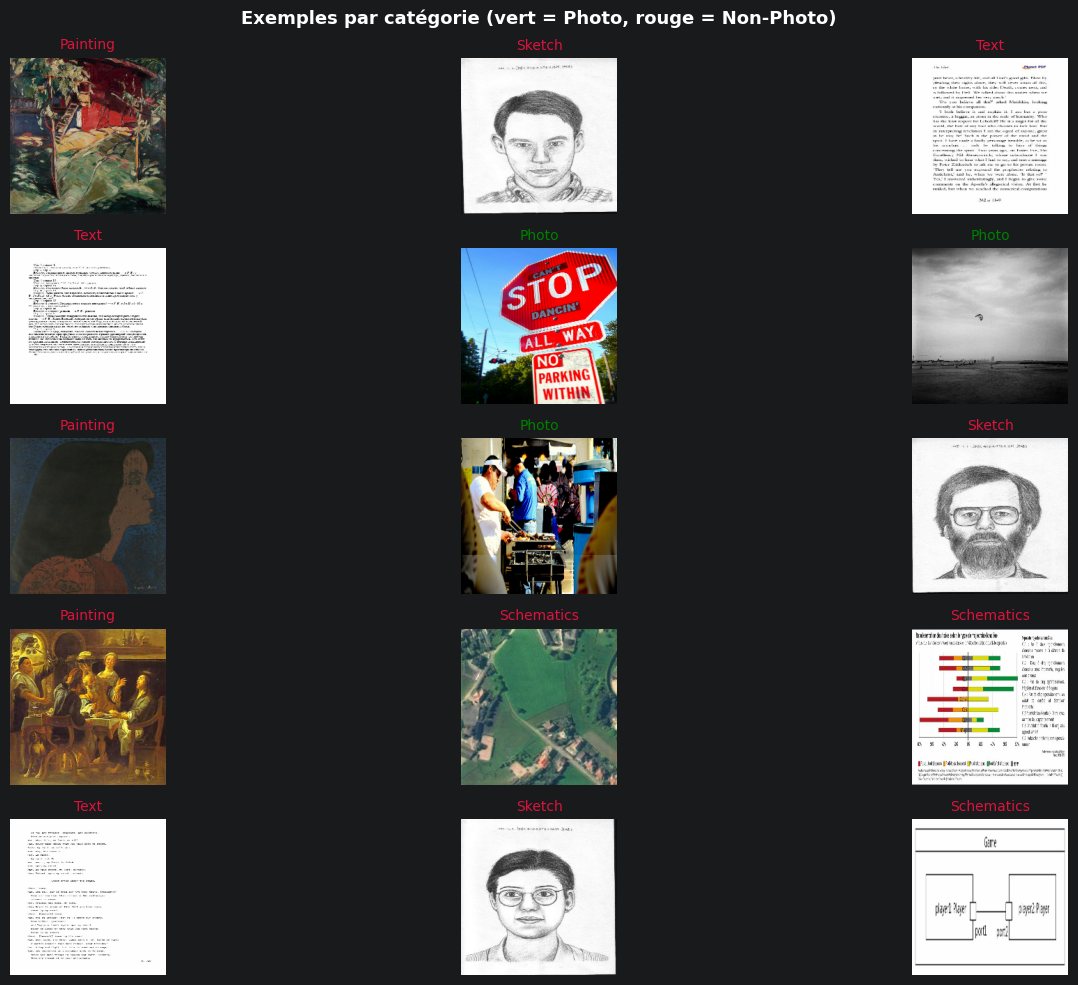

In [5]:
# ─────────────────────────────────────────────────────────────────
# VISUALISATION : grille d'exemples par classe
# ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(16, 10))
seen = {name: 0 for name in class_names}
images_shown = []

for images, labels in train_multi.unbatch().take(200):
    lbl = class_names[labels.numpy()]
    if seen[lbl] < 3:
        images_shown.append((images.numpy().astype('uint8'), lbl))
        seen[lbl] += 1
    if all(v >= 3 for v in seen.values()):
        break

for i, (img, lbl) in enumerate(images_shown):
    ax = plt.subplot(num_classes, 3, i + 1)
    plt.imshow(img)
    plt.title(lbl, fontsize=10,
              color='green' if lbl == 'Photo' else 'crimson')
    plt.axis('off')

plt.suptitle("Exemples par catégorie (vert = Photo, rouge = Non-Photo)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'samples.png', dpi=100, bbox_inches='tight')
plt.show()

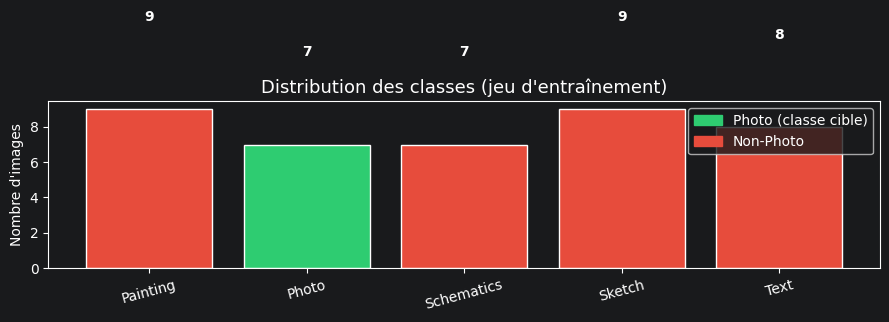


Photos     : 7
Non-Photos : 33  (ratio Non/Photo = 4.7x)
⚠️  Dataset déséquilibré → on utilisera class_weight pour corriger


In [6]:
# ─────────────────────────────────────────────────────────────────
# DISTRIBUTION DES CLASSES
# ─────────────────────────────────────────────────────────────────
label_counts = {name: 0 for name in class_names}
for _, labels in train_multi.unbatch():
    label_counts[class_names[labels.numpy()]] += 1

# Graphique
colors = ['#2ecc71' if k == 'Photo' else '#e74c3c' for k in label_counts]
plt.figure(figsize=(9, 4))
bars = plt.bar(label_counts.keys(), label_counts.values(), color=colors, edgecolor='white')
for bar, v in zip(bars, label_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(v), ha='center', fontsize=10, fontweight='bold')
plt.title("Distribution des classes (jeu d'entraînement)", fontsize=13)
plt.ylabel("Nombre d'images")
plt.xticks(rotation=15)

photo_patch    = mpatches.Patch(color='#2ecc71', label='Photo (classe cible)')
nonphoto_patch = mpatches.Patch(color='#e74c3c', label='Non-Photo')
plt.legend(handles=[photo_patch, nonphoto_patch])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'distribution.png', dpi=100)
plt.show()

n_photo    = label_counts.get('Photo', 0)
n_nonphoto = sum(v for k, v in label_counts.items() if k != 'Photo')
ratio = n_nonphoto / max(n_photo, 1)
print(f"\nPhotos     : {n_photo}")
print(f"Non-Photos : {n_nonphoto}  (ratio Non/Photo = {ratio:.1f}x)")
if ratio > 2:
    print("⚠️  Dataset déséquilibré → on utilisera class_weight pour corriger")

---
## 4. Préparation des données binaires

On transforme les 5 classes en **2 classes** :  
- **1 = Photo** (classe positive, ce qu'on veut trouver)  
- **0 = Not_Photo** (tout le reste)

In [7]:
# ─────────────────────────────────────────────────────────────────
# CONVERSION MULTI-CLASSE → BINAIRE
# ─────────────────────────────────────────────────────────────────
photo_idx = class_names.index('Photo')
print(f"Index 'Photo' dans class_names : {photo_idx}")

def to_binary(images, labels):
    """
    Photo → label 1 (positif)
    Tout le reste → label 0
    On retourne aussi les images normalisées [0,1] ici
    """
    binary_labels = tf.cast(labels == photo_idx, tf.int32)
    return images, binary_labels

AUTOTUNE = tf.data.AUTOTUNE

# Calcul du class_weight pour corriger le déséquilibre
total = n_photo + n_nonphoto
weight_photo    = total / (2 * n_photo)    if n_photo    > 0 else 1.0
weight_nonphoto = total / (2 * n_nonphoto) if n_nonphoto > 0 else 1.0
class_weight = {0: weight_nonphoto, 1: weight_photo}
print(f"\nClass weights : {class_weight}")
print("  (valeurs > 1 = classe minoritaire, le modèle y porte plus d'attention)")

# Pipeline final optimisé
# On recharge le dataset multi non-shufflé pour la conversion propre
train_bin = (train_multi
    .map(to_binary, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000, seed=RANDOM_SEED)
    .prefetch(AUTOTUNE)
)
val_bin = (val_multi
    .map(to_binary, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

print("\n✅ Datasets binaires prêts.")
print("  Classe 1 = Photo")
print("  Classe 0 = Not_Photo (Painting, Schematics, Sketch, Text)")

Index 'Photo' dans class_names : 1

Class weights : {0: 0.6060606060606061, 1: 2.857142857142857}
  (valeurs > 1 = classe minoritaire, le modèle y porte plus d'attention)

✅ Datasets binaires prêts.
  Classe 1 = Photo
  Classe 0 = Not_Photo (Painting, Schematics, Sketch, Text)


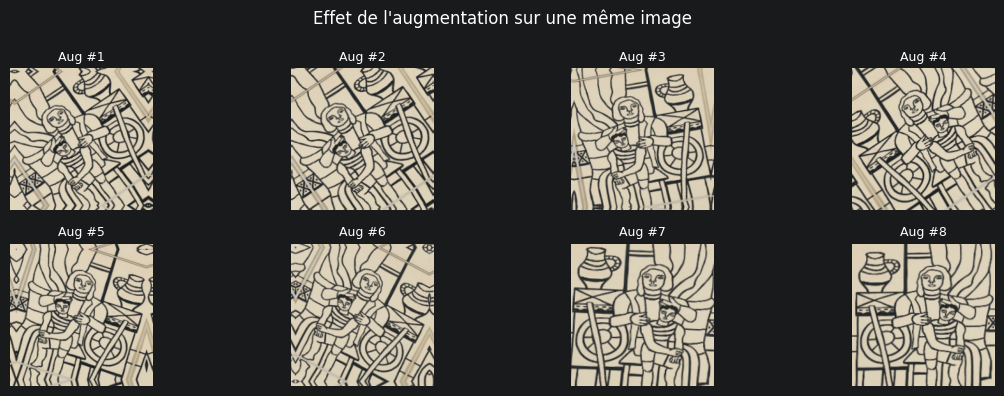

In [8]:
# ─────────────────────────────────────────────────────────────────
# AUGMENTATION DES DONNÉES
# On l'inclura DANS le modèle (s'exécute seulement à l'entraînement)
# ─────────────────────────────────────────────────────────────────
data_augmentation = Sequential([
    RandomFlip('horizontal'),          # miroir horizontal
    RandomRotation(0.1),               # rotation ±36°
    RandomZoom(0.1),                   # zoom ±10%
    RandomContrast(0.1),               # contraste ±10% (aide à distinguer photos/peintures)
], name='augmentation')

# Visualisation de l'augmentation
plt.figure(figsize=(12, 4))
for images, _ in train_bin.take(1):
    img = images[0:1]  # une seule image
    for i in range(8):
        aug = data_augmentation(img, training=True)
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(aug[0].numpy().astype('uint8'))
        plt.title(f'Aug #{i+1}', fontsize=9)
        plt.axis('off')
plt.suptitle('Effet de l\'augmentation sur une même image', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'augmentation.png', dpi=100)
plt.show()

---
## 5. Modèle 1 — CNN from scratch (référence)

### Architecture
```
Input (224×224×3)
  │
  ├── [Augmentation]  RandomFlip / Rotation / Zoom / Contrast
  ├── Rescaling ÷255
  │
  ├── Conv2D(32, 3×3, relu) + BatchNorm + MaxPool(2×2)
  ├── Conv2D(64, 3×3, relu) + BatchNorm + MaxPool(2×2)
  ├── Conv2D(128,3×3, relu) + BatchNorm + MaxPool(2×2)
  ├── Conv2D(256,3×3, relu) + BatchNorm + MaxPool(2×2)
  │
  ├── GlobalAveragePooling2D  (plus robuste que Flatten)
  ├── Dense(256, relu) + BatchNorm + Dropout(0.5)
  └── Dense(1, sigmoid)  → probabilité d'être une Photo
```

| Paramètre | Valeur | Justification |
|---|---|---|
| Optimizer | Adam (lr=1e-3) | Adaptatif, converge vite |
| Loss | BinaryCrossentropy | Tâche binaire |
| Activation sortie | sigmoid | Sortie dans [0,1] → probabilité |
| Dropout | 0.5 | Régularisation forte |
| BatchNorm | après chaque Conv | Stabilise l'entraînement |

In [9]:
def build_cnn(input_shape=(IMAGE_H, IMAGE_W, 3)):
    """Construit un CNN binaire from scratch."""
    model = Sequential(name='CNN_Scratch')

    # Augmentation (désactivée à l'évaluation automatiquement)
    model.add(data_augmentation)
    # Normalisation : pixels [0,255] → [0,1]
    model.add(layers.Rescaling(1./255, input_shape=input_shape))

    # 4 blocs convolutifs croissants
    for filters in [32, 64, 128, 256]:
        model.add(Conv2D(filters, 3, padding='same', activation='relu'))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(2))

    # GlobalAveragePooling : prend la moyenne spatiale → plus robuste que Flatten
    # réduit le risque de surapprentissage vs Flatten + Dense
    model.add(GlobalAveragePooling2D())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    # Sortie binaire : sigmoid → probabilité [0,1]
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer = tf.keras.optimizers.Adam(1e-3),
        loss      = tf.keras.losses.BinaryCrossentropy(),
        metrics   = ['accuracy',
                     tf.keras.metrics.AUC(name='auc'),
                     tf.keras.metrics.Precision(name='precision'),
                     tf.keras.metrics.Recall(name='recall')]
    )
    return model

model_cnn = build_cnn()
model_cnn.summary()

Model: "CNN_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 224, 224, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (1, 224, 224, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 112, 112, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 112, 112, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (1, 112, 112, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 56, 56, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 56, 56, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (1, 56, 56, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (1, 28, 28, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (1, 28, 28, 256)       │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (1, 28, 28, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (1, 14, 14, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (1, 256)               │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 256)               │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (1, 256)               │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 256)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 1)                 │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,409 (1.74 MB)

 Trainable params: 455,937 (1.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [10]:
# ─────────────────────────────────────────────────────────────────
# CALLBACKS
# EarlyStopping      : arrête si val_loss ne s'améliore plus
# ReduceLROnPlateau  : divise le learning rate quand on stagne
# ModelCheckpoint    : sauvegarde le meilleur modèle
# ─────────────────────────────────────────────────────────────────
def get_callbacks(name, patience_stop=8, patience_lr=4):
    return [
        EarlyStopping(
            monitor='val_auc', mode='max',
            patience=patience_stop,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=patience_lr, min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            str(MODELS_DIR / f'{name}_best.keras'),
            monitor='val_auc', mode='max',
            save_best_only=True, verbose=0
        )
    ]

print("✅ Callbacks définis :")
print("  EarlyStopping      patience=8  (sur val_auc)")
print("  ReduceLROnPlateau  patience=4  (÷2 si val_loss stagne)")
print("  ModelCheckpoint    → sauvegarde le meilleur checkpoint")

✅ Callbacks définis :
  EarlyStopping      patience=8  (sur val_auc)
  ReduceLROnPlateau  patience=4  (÷2 si val_loss stagne)
  ModelCheckpoint    → sauvegarde le meilleur checkpoint


In [11]:
print("🚀 Entraînement CNN from scratch...\n")

history_cnn = model_cnn.fit(
    train_bin,
    validation_data = val_bin,
    epochs          = EPOCHS_CNN,
    callbacks       = get_callbacks('cnn_scratch'),
    class_weight    = class_weight,  # correction déséquilibre
    verbose         = 1
)
print("\n✅ Entraînement CNN terminé.")

🚀 Entraînement CNN from scratch...

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5500 - auc: 0.6234 - loss: 1.2350 - precision: 0.2105 - recall: 0.5714 - val_accuracy: 0.7000 - val_auc: 0.7857 - val_loss: 0.6784 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.7500 - auc: 0.9156 - loss: 0.3985 - precision: 0.4000 - recall: 0.8571 - val_accuracy: 0.7000 - val_auc: 0.7857 - val_loss: 0.6761 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8000 - auc: 0.9372 - loss: 0.4070 - precision: 0.4615 - recall: 0.8571 - val_accuracy: 0.7000 - val_auc: 0.0714 - val_loss: 0.6756 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8000 - auc: 0.9589 - loss: 0.3150 - precision: 0.4667 - recall: 1.0000 - val_accuracy: 0.7000 - 

---
## 6. Modèle 2 — MobileNetV2 (Transfer Learning) ✦ Modèle principal

### Justification du Transfer Learning

MobileNetV2 a été entraîné sur **ImageNet** (1,2 million d'images, 1000 classes).  
Il a appris à détecter des textures, formes et structures présentes dans les vraies photographies.  
Ces caractéristiques sont exactement ce qui permet de distinguer une **photo** d'une **peinture** ou d'un **schéma**.

### Stratégie en deux phases

```
Phase 1 — Feature Extraction
  MobileNetV2 (poids gelés) → on entraîne seulement le nouveau head
  Rapide, évite de "casser" les features apprises

Phase 2 — Fine-tuning
  On dégèle les 30 dernières couches de MobileNetV2
  On ré-entraîne avec un lr très faible (1e-5)
  Le modèle s'adapte finement à nos images
```

### Architecture
```
Input (224×224×3)
  │
  ├── [Augmentation]
  ├── MobileNetV2 (pré-entraîné ImageNet, poids gelés phase 1)
  │     ↓ feature maps 7×7×1280
  ├── GlobalAveragePooling2D  → vecteur 1280
  ├── Dense(128, relu) + BatchNorm + Dropout(0.3)
  └── Dense(1, sigmoid)  → probabilité Photo
```

In [12]:
def build_mobilenet(input_shape=(IMAGE_H, IMAGE_W, 3), freeze_base=True):
    """
    Construit un modèle binaire basé sur MobileNetV2 pré-entraîné.

    freeze_base=True  → Phase 1 : feature extraction (base gelée)
    freeze_base=False → Phase 2 : fine-tuning (dernières couches dégelées)
    """
    # Couche d'entrée explicite (nécessaire pour l'augmentation)
    inputs = tf.keras.Input(shape=input_shape)

    # Augmentation
    x = data_augmentation(inputs)

    # Normalisation au format attendu par MobileNetV2 : [-1, 1]
    # (différent du ÷255 classique)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    # Base MobileNetV2 pré-entraînée
    # include_top=False : on enlève le head de classification ImageNet
    base = MobileNetV2(
        input_shape = input_shape,
        include_top = False,
        weights     = 'imagenet'   # charge les poids ImageNet
    )

    if freeze_base:
        # Phase 1 : gèle TOUT le base model
        base.trainable = False
    else:
        # Phase 2 : dégèle les 30 dernières couches
        base.trainable = True
        for layer in base.layers[:-30]:
            layer.trainable = False

    # Passage dans le base model
    x = base(x, training=False)   # training=False → BatchNorm en mode inférence

    # Head de classification personnalisé
    x = GlobalAveragePooling2D()(x)       # 1280-dim feature vector
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)                   # dropout plus léger (base déjà régularisée)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='MobileNetV2_Binary')

    n_trainable = sum(1 for l in model.layers if l.trainable)
    n_frozen    = sum(1 for l in model.layers if not l.trainable)
    print(f"  Couches entraînables : {n_trainable} | Gelées : {n_frozen}")
    return model


# ─────────────────────────────────────────────────────────────────
# PHASE 1 : Feature Extraction
# ─────────────────────────────────────────────────────────────────
print("📦 Construction du modèle MobileNetV2 — Phase 1 (feature extraction)")
model_tl = build_mobilenet(freeze_base=True)

model_tl.compile(
    optimizer = tf.keras.optimizers.Adam(1e-3),
    loss      = tf.keras.losses.BinaryCrossentropy(),
    metrics   = ['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
)
model_tl.summary()

📦 Construction du modèle MobileNetV2 — Phase 1 (feature extraction)
  Couches entraînables : 7 | Gelées : 1


Model: "MobileNetV2_Binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [13]:
print("🚀 Phase 1 — Entraînement (base MobileNetV2 gelée)...\n")

history_tl_phase1 = model_tl.fit(
    train_bin,
    validation_data = val_bin,
    epochs          = EPOCHS_TRANSFER,
    callbacks       = get_callbacks('mobilenet_phase1'),
    class_weight    = class_weight,
    verbose         = 1
)
print("\n✅ Phase 1 terminée.")

🚀 Phase 1 — Entraînement (base MobileNetV2 gelée)...

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5000 - auc: 0.6061 - loss: 0.8437 - precision: 0.2174 - recall: 0.7143 - val_accuracy: 0.6000 - val_auc: 0.3810 - val_loss: 0.8038 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step - accuracy: 0.7000 - auc: 0.9351 - loss: 0.4202 - precision: 0.3684 - recall: 1.0000 - val_accuracy: 0.7000 - val_auc: 0.6667 - val_loss: 0.6882 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step - accuracy: 0.8000 - auc: 1.0000 - loss: 0.2599 - precision: 0.4667 - recall: 1.0000 - val_accuracy: 0.7000 - val_auc: 0.8571 - val_loss: 0.5545 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - accuracy: 0.8750 - auc: 1.0000 - loss: 0.2258 - precision: 0.5833 - recall: 1.000

In [14]:
# ─────────────────────────────────────────────────────────────────
# PHASE 2 : Fine-tuning
# On dégèle les 30 dernières couches de MobileNetV2
# Learning rate TRÈS faible pour ne pas détruire les poids appris
# ─────────────────────────────────────────────────────────────────
print("🔧 Phase 2 — Fine-tuning (30 dernières couches dégelées)...")

# Dégeler les dernières couches de la base
base_model = model_tl.layers[3]  # couche MobileNetV2
base_model.trainable = True
base_model = model_tl.layers[2]  # MobileNetV2 layer (index 2, not 3)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

n_trainable = sum(1 for l in model_tl.trainable_variables)
print(f"  Variables entraînables : {n_trainable}")

# Recompiler avec lr TRÈS faible (1e-5 = 100x plus faible qu'avant)
model_tl.compile(
    optimizer = tf.keras.optimizers.Adam(1e-5),
    loss      = tf.keras.losses.BinaryCrossentropy(),
    metrics   = ['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
)

history_tl_phase2 = model_tl.fit(
    train_bin,
    validation_data = val_bin,
    epochs          = EPOCHS_FINETUNE,
    callbacks       = get_callbacks('mobilenet_finetune', patience_stop=5, patience_lr=3),
    class_weight    = class_weight,
    verbose         = 1
)
print("\n✅ Fine-tuning terminé.")

🔧 Phase 2 — Fine-tuning (30 dernières couches dégelées)...
  Variables entraînables : 38
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8250 - auc: 1.0000 - loss: 0.2099 - precision: 0.5000 - recall: 1.0000 - val_accuracy: 0.8000 - val_auc: 0.9048 - val_loss: 0.4286 - val_precision: 0.6667 - val_recall: 0.6667 - learning_rate: 1.0000e-05
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step - accuracy: 0.7500 - auc: 1.0000 - loss: 0.2259 - precision: 0.4118 - recall: 1.0000 - val_accuracy: 0.8000 - val_auc: 0.9048 - val_loss: 0.4308 - val_precision: 0.6667 - val_recall: 0.6667 - learning_rate: 1.0000e-05
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step - accuracy: 0.8750 - auc: 1.0000 - loss: 0.1810 - precision: 0.5833 - recall: 1.0000 - val_accuracy: 0.8000 - val_auc: 0.9048 - val_loss: 0.4334 - val_precision: 0.6667 - val_recall: 0.6667 - learning_rate: 1.0000e-05
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.9250 - auc: 1.0000 - loss: 0.1415 - precision

---
## 7. Visualisation des courbes d'entraînement

### Rappel — Compromis biais / variance

| Situation | Train acc | Val acc | Diagnostic | Solution |
|---|---|---|---|---|
| **Sous-apprentissage (biais élevé)** | Faible | Faible | Modèle trop simple | Plus de couches, plus d'epochs |
| **Sur-apprentissage (variance élevée)** | Élevée | Faible | Modèle trop complexe | Dropout, BN, augmentation, early stopping |
| **Bon équilibre** | Élevée | Élevée (≈ train) | ✅ | — |

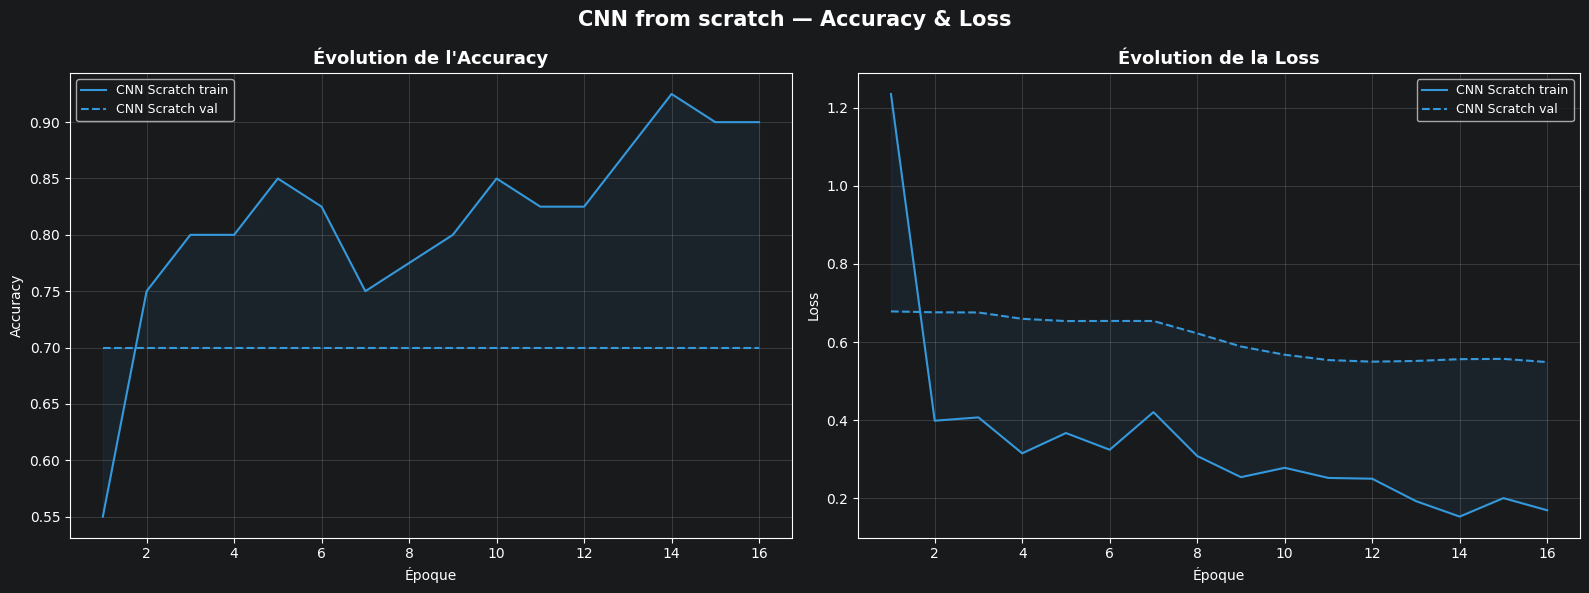

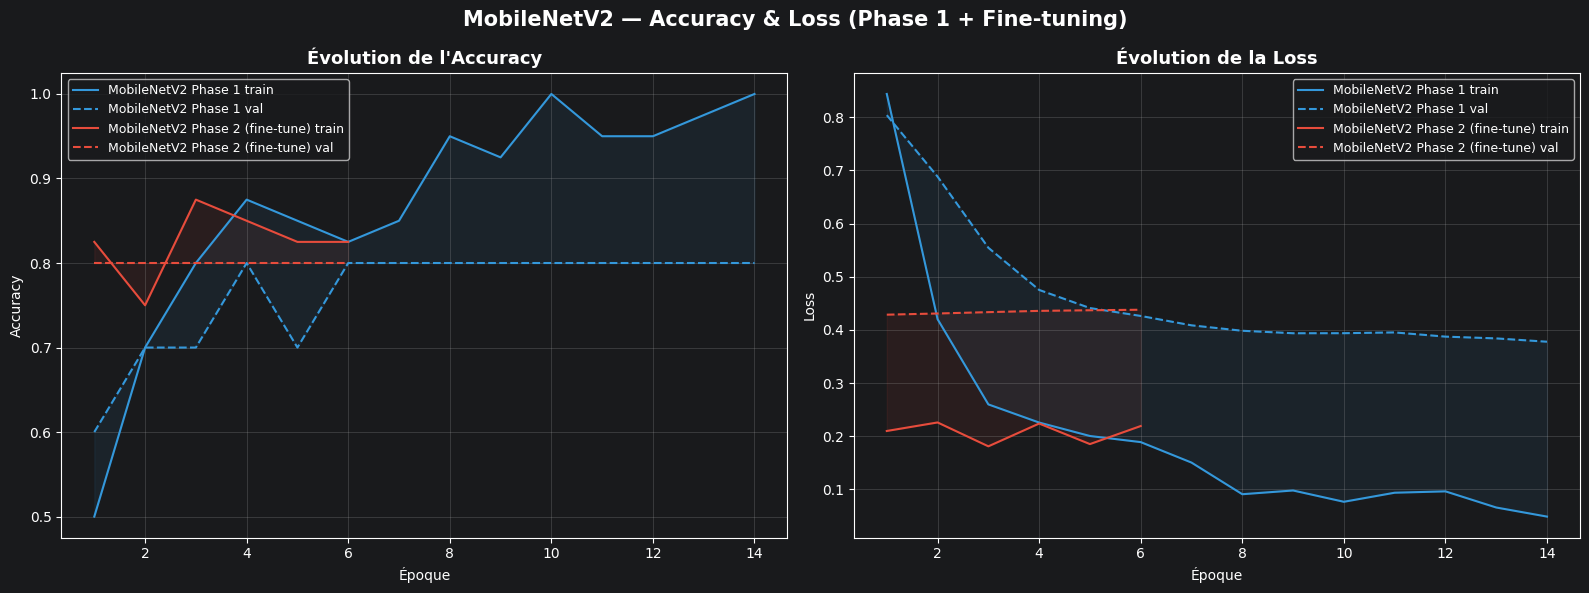

In [15]:
def plot_history(history_list, labels, title, save_path=None):
    """
    Affiche les courbes accuracy et loss pour un ou plusieurs historiques.
    Affiche aussi une zone colorée entre train et val pour visualiser l'écart.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

    for idx, (h, label) in enumerate(zip(history_list, labels)):
        hist = h.history
        ep   = range(1, len(hist['accuracy']) + 1)
        c    = colors[idx % len(colors)]

        # Accuracy
        axes[0].plot(ep, hist['accuracy'],     color=c,  label=f'{label} train')
        axes[0].plot(ep, hist['val_accuracy'], color=c,  label=f'{label} val',
                     linestyle='--')
        # Zone entre train et val (visualise le sur-apprentissage)
        axes[0].fill_between(ep, hist['accuracy'], hist['val_accuracy'],
                              alpha=0.08, color=c)

        # Loss
        axes[1].plot(ep, hist['loss'],     color=c, label=f'{label} train')
        axes[1].plot(ep, hist['val_loss'], color=c, label=f'{label} val',
                     linestyle='--')
        axes[1].fill_between(ep, hist['loss'], hist['val_loss'],
                              alpha=0.08, color=c)

    for ax, ylabel, subtitle in zip(
        axes,
        ['Accuracy', 'Loss'],
        ['Évolution de l\'Accuracy', 'Évolution de la Loss']
    ):
        ax.set_title(subtitle, fontsize=13, fontweight='bold')
        ax.set_xlabel('Époque')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()


# CNN from scratch
plot_history(
    [history_cnn], ['CNN Scratch'],
    'CNN from scratch — Accuracy & Loss',
    FIGURES_DIR / 'curves_cnn.png'
)

# MobileNetV2 (concaténer les deux phases)
def merge_histories(h1, h2):
    """Fusionne deux historiques Keras pour les afficher en continu."""
    merged = {}
    for k in h1.history:
        if k in h2.history:
            merged[k] = h1.history[k] + h2.history[k]
    class FakeHistory:
        def __init__(self, d): self.history = d
    return FakeHistory(merged)

history_tl_full = merge_histories(history_tl_phase1, history_tl_phase2)

plot_history(
    [history_tl_phase1, history_tl_phase2],
    ['MobileNetV2 Phase 1', 'MobileNetV2 Phase 2 (fine-tune)'],
    'MobileNetV2 — Accuracy & Loss (Phase 1 + Fine-tuning)',
    FIGURES_DIR / 'curves_mobilenet.png'
)

---
## 8. Évaluation détaillée


 📊 ÉVALUATION — CNN Scratch

📈 Métriques de validation :
  loss            : 0.6222
  compile_metrics : 0.7000
  AUC-ROC         : 0.8095

📋 Rapport de classification :
              precision    recall  f1-score   support

   Not_Photo       0.70      1.00      0.82         7
       Photo       0.00      0.00      0.00         3

    accuracy                           0.70        10
   macro avg       0.35      0.50      0.41        10
weighted avg       0.49      0.70      0.58        10



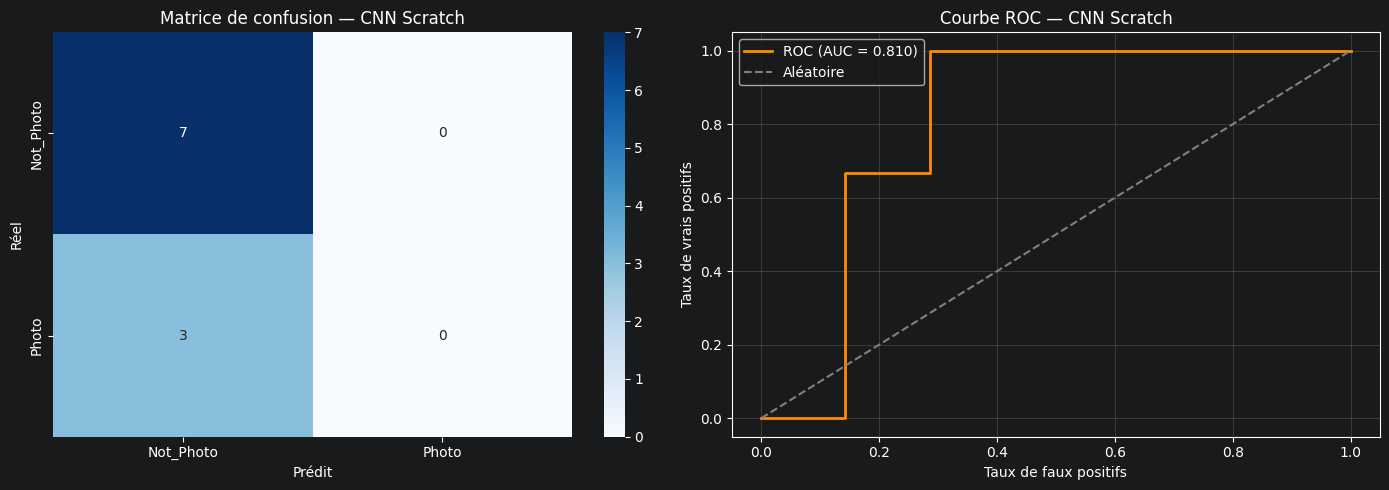

{'loss': 0.5792363286018372, 'compile_metrics': 0.824999988079071}

🔍 Analyse biais / variance :
  Train accuracy : 0.8250
  Val   accuracy : 0.7000
  Écart           : 0.1250
  ⚠️  Sous-apprentissage (biais élevé) — augmenter capacité du modèle

 📊 ÉVALUATION — MobileNetV2

📈 Métriques de validation :
  loss            : 0.4286
  compile_metrics : 0.8000
  AUC-ROC         : 0.9048

📋 Rapport de classification :
              precision    recall  f1-score   support

   Not_Photo       0.86      0.86      0.86         7
       Photo       0.67      0.67      0.67         3

    accuracy                           0.80        10
   macro avg       0.76      0.76      0.76        10
weighted avg       0.80      0.80      0.80        10



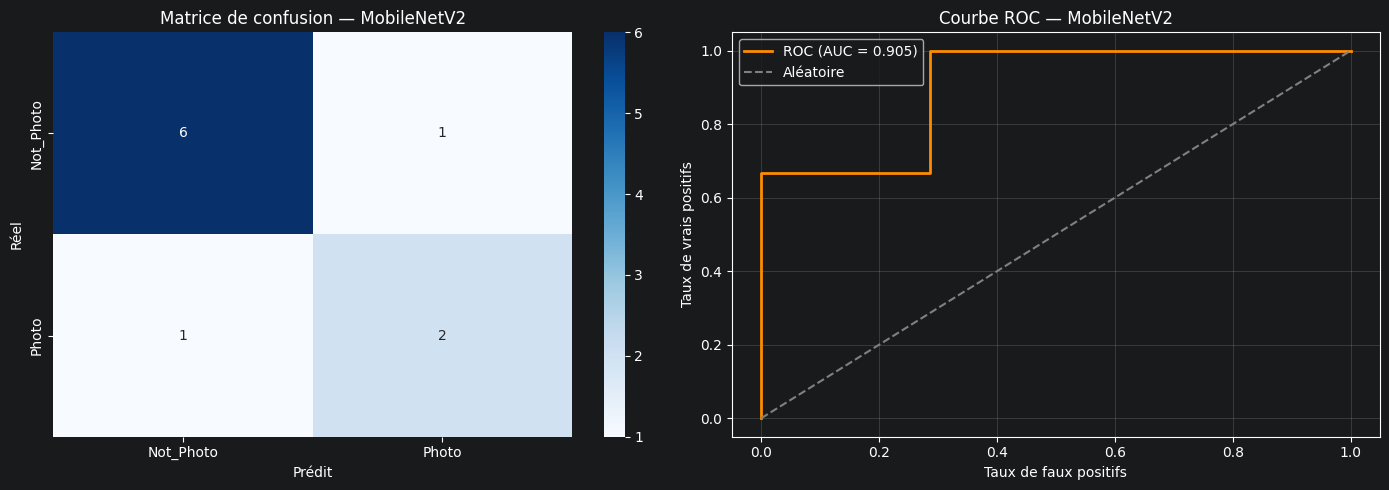

{'loss': 0.035932507365942, 'compile_metrics': 1.0}

🔍 Analyse biais / variance :
  Train accuracy : 1.0000
  Val   accuracy : 0.8000
  Écart           : 0.2000
  ⚠️  Sur-apprentissage (variance élevée) — renforcer régularisation


In [16]:
def full_evaluation(model, val_dataset, model_name, threshold=THRESHOLD):
    """
    Évaluation complète : métriques, matrice de confusion, courbe ROC.
    """
    print(f"\n{'='*60}")
    print(f" 📊 ÉVALUATION — {model_name}")
    print(f"{'='*60}")

    # Prédictions sur le jeu de validation
    y_true, y_pred_prob = [], []
    for images, labels in val_dataset:
        probs = model.predict(images, verbose=0).flatten()
        y_pred_prob.extend(probs.tolist())
        y_true.extend(labels.numpy().tolist())

    y_true      = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_pred      = (y_pred_prob >= threshold).astype(int)

    # Métriques de base
    results = model.evaluate(val_dataset, verbose=0)
    metric_names = [m.name for m in model.metrics]
    metrics_dict = dict(zip(metric_names, results))

    print("\n📈 Métriques de validation :")
    for k, v in metrics_dict.items():
        print(f"  {k:<15} : {v:.4f}")

    # AUC-ROC
    auc = roc_auc_score(y_true, y_pred_prob)
    print(f"  {'AUC-ROC':<15} : {auc:.4f}")

    # Rapport de classification
    print("\n📋 Rapport de classification :")
    print(classification_report(y_true, y_pred,
                                target_names=['Not_Photo', 'Photo']))

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not_Photo', 'Photo'],
                yticklabels=['Not_Photo', 'Photo'], ax=axes[0])
    axes[0].set_xlabel('Prédit')
    axes[0].set_ylabel('Réel')
    axes[0].set_title(f'Matrice de confusion — {model_name}')

    # Courbe ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC (AUC = {auc:.3f})')
    axes[1].plot([0,1],[0,1], color='gray', linestyle='--', label='Aléatoire')
    axes[1].set_xlabel('Taux de faux positifs')
    axes[1].set_ylabel('Taux de vrais positifs')
    axes[1].set_title(f'Courbe ROC — {model_name}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'eval_{model_name.lower().replace(" ","_")}.png',
                dpi=100, bbox_inches='tight')
    plt.show()

    # Analyse biais / variance
    train_res  = model.evaluate(train_bin, verbose=0)
    train_dict = dict(zip(metric_names, train_res))
    print(train_dict)
    train_acc  = train_dict['compile_metrics']
    val_acc    = metrics_dict['compile_metrics']
    gap        = train_acc - val_acc

    print("\n🔍 Analyse biais / variance :")
    print(f"  Train accuracy : {train_acc:.4f}")
    print(f"  Val   accuracy : {val_acc:.4f}")
    print(f"  Écart           : {gap:.4f}")
    if val_acc < 0.70:
        print("  ⚠️  Sous-apprentissage (biais élevé) — augmenter capacité du modèle")
    elif gap > 0.15:
        print("  ⚠️  Sur-apprentissage (variance élevée) — renforcer régularisation")
    elif gap > 0.08:
        print("  ~ Légère variance — acceptable, surveiller")
    else:
        print("  ✅ Bon équilibre biais/variance")

    return {'model_name': model_name, 'val_acc': val_acc,
            'train_acc': train_acc, 'auc': auc, 'gap': gap,
            **metrics_dict}


# Évaluation des deux modèles
# Évaluation des deux modèles
results_cnn = full_evaluation(model_cnn, val_bin, 'CNN Scratch')
results_tl  = full_evaluation(model_tl,  val_bin, 'MobileNetV2')

---
## 9. Comparaison des modèles


══════════════════════════════════════════════════════════════════════
 📊 TABLEAU COMPARATIF
══════════════════════════════════════════════════════════════════════
 model_name  train_acc  val_acc   gap      auc
CNN Scratch      0.825      0.7 0.125 0.809524
MobileNetV2      1.000      0.8 0.200 0.904762
══════════════════════════════════════════════════════════════════════


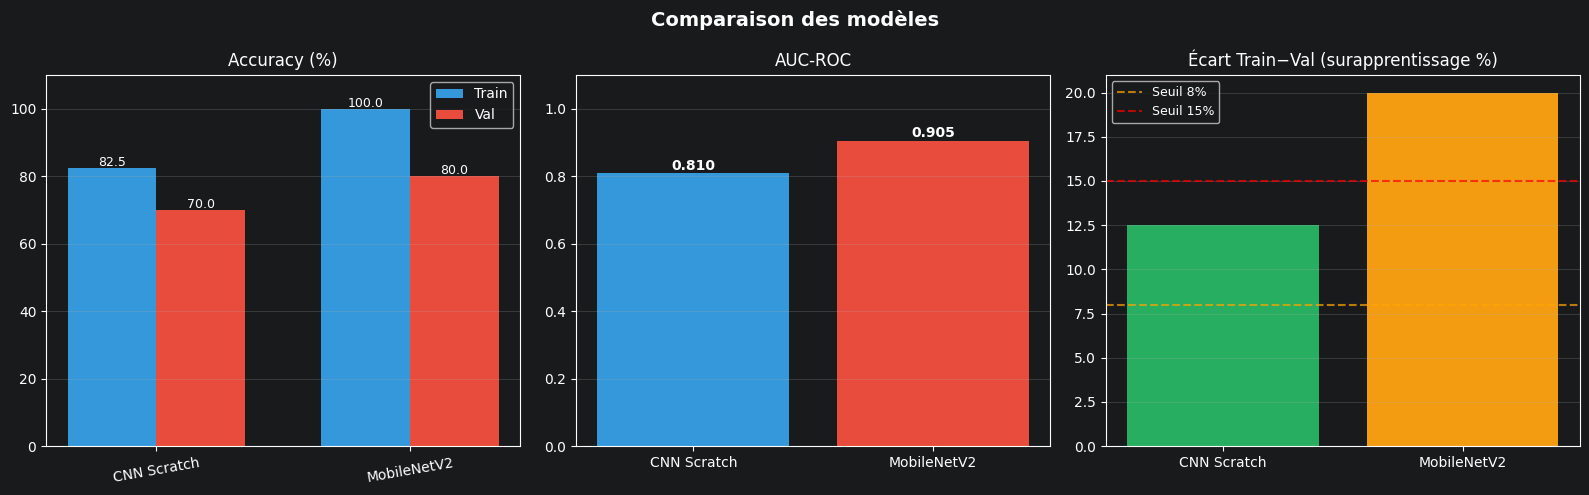


🏆 Meilleur modèle : MobileNetV2  (AUC = 0.9048)


In [17]:
# Tableau comparatif
comparison = pd.DataFrame([results_cnn, results_tl])
cols = ['model_name', 'train_acc', 'val_acc', 'gap', 'auc', 'precision', 'recall']
cols_present = [c for c in cols if c in comparison.columns]

print("\n" + "═"*70)
print(" 📊 TABLEAU COMPARATIF")
print("═"*70)
print(comparison[cols_present].to_string(index=False))
print("═"*70)

# Graphique comparatif
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_names = comparison['model_name'].tolist()
x = np.arange(len(models_names))
w = 0.35
colors_pair = ['#3498db', '#e74c3c']

# Accuracy
b1 = axes[0].bar(x - w/2, comparison['train_acc']*100, w,
                  label='Train', color='#3498db')
b2 = axes[0].bar(x + w/2, comparison['val_acc']*100,   w,
                  label='Val',   color='#e74c3c')
axes[0].set_title('Accuracy (%)')
axes[0].set_xticks(x); axes[0].set_xticklabels(models_names, rotation=10)
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, 110)
for bar in list(b1)+list(b2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{bar.get_height():.1f}', ha='center', fontsize=9)

# AUC
axes[1].bar(models_names, comparison['auc'], color=['#3498db','#e74c3c'])
axes[1].set_title('AUC-ROC')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(comparison['auc']):
    axes[1].text(i, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Écart Train/Val (surapprentissage)
axes[2].bar(models_names, comparison['gap']*100, color=['#27ae60','#f39c12'])
axes[2].axhline(y=8,  color='orange', linestyle='--', alpha=0.7, label='Seuil 8%')
axes[2].axhline(y=15, color='red',    linestyle='--', alpha=0.7, label='Seuil 15%')
axes[2].set_title('Écart Train−Val (surapprentissage %)')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparaison des modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# Modèle gagnant
best_idx   = comparison['auc'].idxmax()
best_model = comparison.loc[best_idx, 'model_name']
best_auc   = comparison.loc[best_idx, 'auc']
print(f"\n🏆 Meilleur modèle : {best_model}  (AUC = {best_auc:.4f})")

---
## 10. Tri automatique des images → `data/processed/`

On utilise le **meilleur modèle** pour classer **toutes** les images du dataset  
et les copier dans :
- `data/processed/Photo/`     ← images identifiées comme photos
- `data/processed/Not_Photo/` ← tout le reste

In [18]:
# ─────────────────────────────────────────────────────────────────
# SÉLECTION DU MEILLEUR MODÈLE
# ─────────────────────────────────────────────────────────────────
best_model_obj = model_tl if results_tl['auc'] >= results_cnn['auc'] else model_cnn
print(f"Modèle utilisé pour le tri : {best_model_obj.name}")

def classify_and_sort_images(
    model, data_path, output_path,
    image_size=(IMAGE_H, IMAGE_W),
    threshold=THRESHOLD,
    batch_size=32
):
    """
    Prédit la classe (Photo / Not_Photo) de chaque image dans data_path
    et copie chaque fichier dans output_path/Photo/ ou output_path/Not_Photo/.

    Retourne un résumé avec le nombre d'images triées par classe.
    """
    dest_photo     = output_path / 'Photo'
    dest_not_photo = output_path / 'Not_Photo'
    dest_photo.mkdir(parents=True, exist_ok=True)
    dest_not_photo.mkdir(parents=True, exist_ok=True)

    EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    summary = {'Photo': 0, 'Not_Photo': 0, 'errors': 0, 'details': []}

    # Collecter toutes les images
    all_images = []
    for folder in sorted(data_path.iterdir()):
        if folder.is_dir():
            for f in sorted(folder.iterdir()):
                if f.suffix.lower() in EXTENSIONS:
                    all_images.append((f, folder.name))

    total = len(all_images)
    print(f"\n🔄 Traitement de {total} images...\n")

    # Traitement par batch
    for batch_start in range(0, total, batch_size):
        batch = all_images[batch_start:batch_start + batch_size]
        imgs_tensors = []
        valid_batch  = []

        for img_path, original_class in batch:
            try:
                raw   = tf.io.read_file(str(img_path))
                img   = tf.io.decode_image(raw, channels=3, expand_animations=False)
                img   = tf.image.resize(img, image_size)
                imgs_tensors.append(img)
                valid_batch.append((img_path, original_class))
            except Exception as e:
                summary['errors'] += 1
                print(f"  ⚠️  Erreur lecture {img_path.name}: {e}")

        if not imgs_tensors:
            continue

        # Prédiction batch
        batch_tensor = tf.stack(imgs_tensors)  # (batch, H, W, 3)
        probs = model.predict(batch_tensor, verbose=0).flatten()

        for (img_path, original_class), prob in zip(valid_batch, probs):
            is_photo = prob >= threshold
            dest_class = 'Photo' if is_photo else 'Not_Photo'
            dest_dir   = dest_photo if is_photo else dest_not_photo

            # Conserver le dossier source dans le nom pour la traçabilité
            new_name = f"{original_class}__{img_path.name}"
            dest_file = dest_dir / new_name

            # Éviter les doublons de noms
            counter = 1
            while dest_file.exists():
                stem = f"{original_class}__{img_path.stem}_{counter}"
                dest_file = dest_dir / f"{stem}{img_path.suffix}"
                counter += 1

            shutil.copy2(str(img_path), str(dest_file))
            summary[dest_class] += 1
            summary['details'].append({
                'file'          : img_path.name,
                'original_class': original_class,
                'predicted'     : dest_class,
                'probability'   : round(float(prob), 4)
            })

        # Affichage de la progression
        done = min(batch_start + batch_size, total)
        print(f"  [{done:>{len(str(total))}}/{total}]  "
              f"Photo: {summary['Photo']}  /  Not_Photo: {summary['Not_Photo']}",
              end='\r')

    print(f"\n\n{'='*55}")
    print(" ✅ TRI TERMINÉ")
    print(f"{'='*55}")
    print(f"  📸 Photo     : {summary['Photo']} images → {dest_photo}")
    print(f"  🚫 Not_Photo : {summary['Not_Photo']} images → {dest_not_photo}")
    if summary['errors']:
        print(f"  ⚠️  Erreurs   : {summary['errors']} images ignorées")
    precision_estimate = summary['Photo'] / max(summary['Photo'] + summary['Not_Photo'], 1)
    print(f"\n  Ratio Photo  : {precision_estimate:.1%} des images totales")
    return summary


# ─── LANCEMENT DU TRI ───
sort_summary = classify_and_sort_images(
    model      = best_model_obj,
    data_path  = DATA_RAW,
    output_path= DATA_PROC,
    threshold  = THRESHOLD
)

Modèle utilisé pour le tri : MobileNetV2_Binary

🔄 Traitement de 50 images...

  [50/50]  Photo: 10  /  Not_Photo: 40

 ✅ TRI TERMINÉ
  📸 Photo     : 10 images → ..\data\processed\Photo
  🚫 Not_Photo : 40 images → ..\data\processed\Not_Photo

  Ratio Photo  : 20.0% des images totales


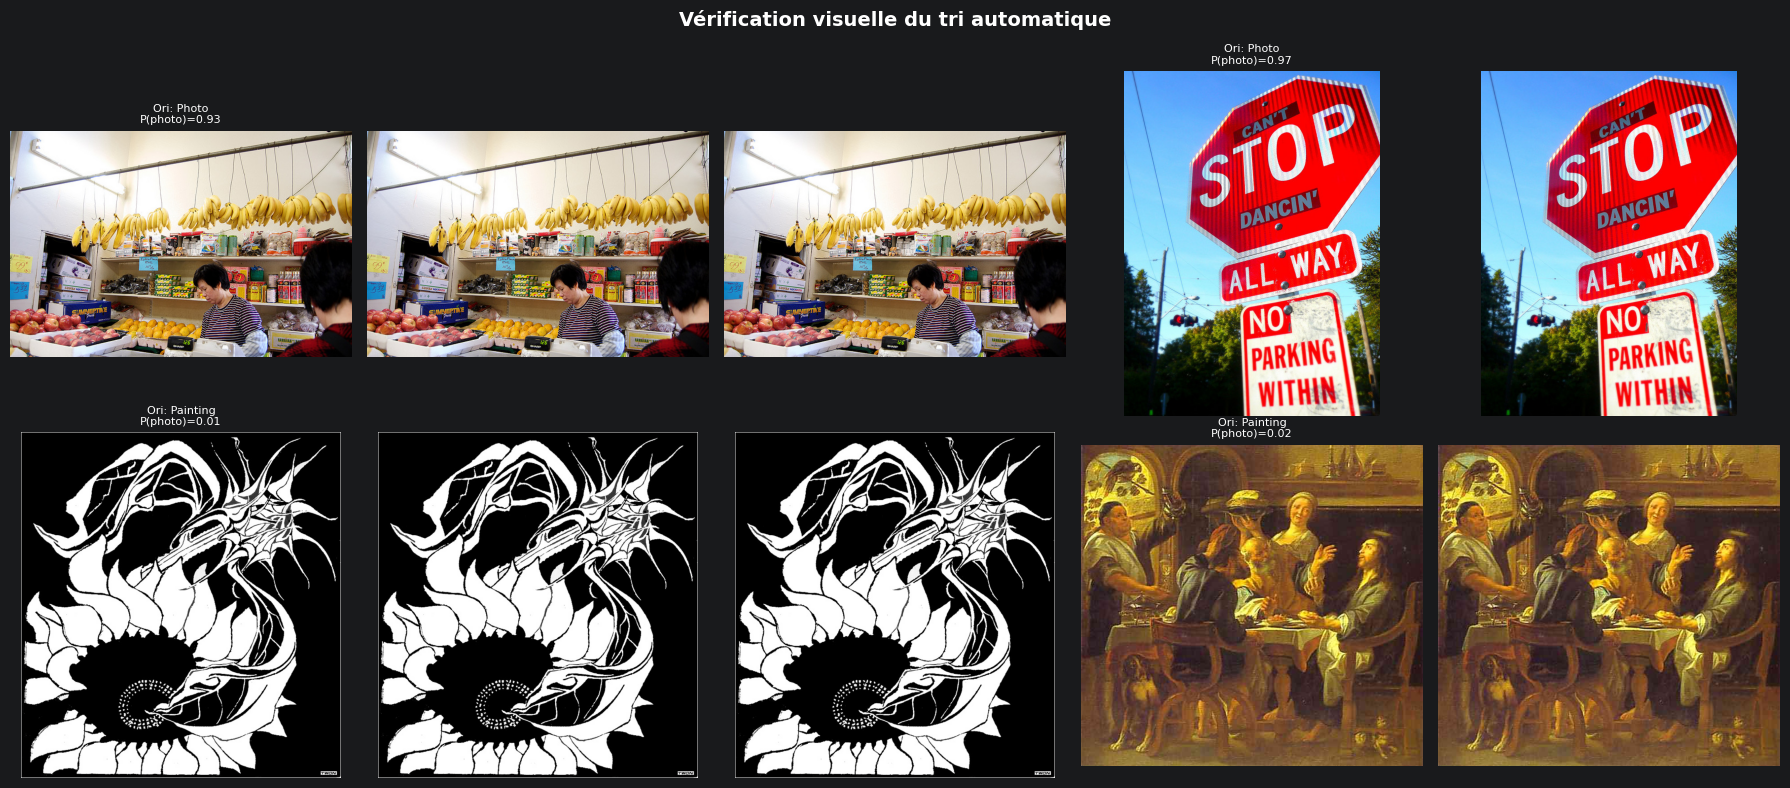

In [19]:
# ─────────────────────────────────────────────────────────────────
# VÉRIFICATION VISUELLE DU TRI
# Affiche un échantillon d'images triées dans chaque catégorie
# ─────────────────────────────────────────────────────────────────
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for row_idx, (cat, folder) in enumerate(
    [('Photo', DATA_PROC / 'Photo'),
     ('Not_Photo', DATA_PROC / 'Not_Photo')]
):
    imgs = sorted(list(folder.glob('*.*')))[:5]
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        if col_idx < len(imgs):
            try:
                img = mpimg.imread(str(imgs[col_idx]))
                ax.imshow(img)
                # Chercher le détail de prédiction
                fname = imgs[col_idx].name
                detail = next(
                    (d for d in sort_summary['details'] if fname.endswith(d['file'])),
                    None
                )
                if detail:
                    ax.set_title(
                        f"Ori: {detail['original_class']}\n"
                        f"P(photo)={detail['probability']:.2f}",
                        fontsize=8
                    )
            except:
                pass
        ax.axis('off')

    axes[row_idx, 0].set_ylabel(
        f"→ {cat}",
        fontsize=12, fontweight='bold',
        color='green' if cat == 'Photo' else 'crimson',
        rotation=0, labelpad=70
    )

plt.suptitle('Vérification visuelle du tri automatique', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sorted_samples.png', dpi=100, bbox_inches='tight')
plt.show()

In [20]:
# ─────────────────────────────────────────────────────────────────
# ANALYSE DES ERREURS DE CLASSIFICATION
# Affiche les peintures classées comme photos (cas difficiles)
# ─────────────────────────────────────────────────────────────────
painting_as_photo = [
    d for d in sort_summary['details']
    if d['original_class'] == 'Painting' and d['predicted'] == 'Photo'
]
# Triés par confiance décroissante (les plus confiants en premier)
painting_as_photo.sort(key=lambda x: x['probability'], reverse=True)

print(f"\n🎨 Peintures classées comme Photos : {len(painting_as_photo)}")
print("   (Ce sont les cas les plus difficiles — peintures hyper-réalistes)")

if painting_as_photo:
    n_show = min(10, len(painting_as_photo))
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    for i, d in enumerate(painting_as_photo[:n_show]):
        # Retrouver l'image dans data/processed/Photo
        img_path = DATA_PROC / 'Photo' / f"Painting__{d['file']}"
        if not img_path.exists():
            # Chercher avec un pattern
            candidates = list((DATA_PROC / 'Photo').glob(f"Painting__*{d['file']}"))
            img_path = candidates[0] if candidates else None

        ax = axes[i // 5, i % 5]
        if img_path and img_path.exists():
            ax.imshow(mpimg.imread(str(img_path)))
            ax.set_title(f"P(photo)={d['probability']:.2f}", fontsize=9, color='red')
        ax.axis('off')

    plt.suptitle('Peintures mal classées comme Photos\n(peintures réalistes difficiles à distinguer)',
                 fontsize=13, color='red')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'hard_cases.png', dpi=100)
    plt.show()


🎨 Peintures classées comme Photos : 0
   (Ce sont les cas les plus difficiles — peintures hyper-réalistes)


---
## 11. Analyse biais/variance & méthodes d'amélioration

### 11.1 Biais vs Variance

| Concept | Définition | Se voit sur les courbes |
|---|---|---|
| **Biais (sous-apprentissage)** | Le modèle est trop simple pour capturer la complexité des données | Train acc ET val acc faibles |
| **Variance (sur-apprentissage)** | Le modèle mémorise le train sans généraliser | Train acc haute, val acc basse, écart important |

### 11.2 Techniques de régularisation utilisées

| Technique | Comment ça marche | Dans notre modèle |
|---|---|---|
| **Dropout** | Désactive aléatoirement des neurones → force la redondance | `Dropout(0.3)` avant la sortie |
| **BatchNormalization** | Normalise les activations → entraînement plus stable | Après chaque couche Dense |
| **Augmentation** | Crée de la variété artificielle → meilleure généralisation | `RandomFlip/Rotation/Zoom/Contrast` |
| **Early Stopping** | Arrête quand val_loss stagne | `patience=8` sur `val_auc` |
| **ReduceLROnPlateau** | Réduit le lr si plateau → fine-tune plus précis | `factor=0.5`, `patience=4` |
| **Class Weight** | Compense le déséquilibre Photo/NonPhoto | `class_weight={0: w0, 1: w1}` |
| **Transfer Learning** | Utilise des features déjà apprises → moins d'overfitting avec peu de données | MobileNetV2 ImageNet |

### 11.3 Axes d'amélioration possibles

1. **Plus de données** : les peintures réalistes nécessitent plus d'exemples
2. **EfficientNetV2** : meilleure précision que MobileNetV2 (mais plus lent)
3. **Ajustement du seuil** : si les faux positifs (peintures → photo) sont coûteux, baisser le threshold
4. **Ensemble de modèles** : combiner CNN Scratch + MobileNetV2 par vote
5. **Focal Loss** : pénalise davantage les erreurs sur les cas difficiles (peintures réalistes)

---
## 12. Sauvegarde des modèles & métadonnées

In [21]:
# Sauvegarde des modèles
model_cnn.save(str(MODELS_DIR / 'cnn_scratch.keras'))
model_tl.save(str(MODELS_DIR  / 'mobilenetv2.keras'))
print(f"✅ Modèles sauvegardés dans {MODELS_DIR}")

# Métadonnées JSON
metadata = {
    'project'     : 'Leyenda — Livrable 2',
    'group'       : 'Groupe 3',
    'threshold'   : THRESHOLD,
    'image_size'  : [IMAGE_H, IMAGE_W],
    'classes'     : {'0': 'Not_Photo', '1': 'Photo'},
    'sort_summary': {
        'n_photo'    : sort_summary['Photo'],
        'n_not_photo': sort_summary['Not_Photo'],
        'errors'     : sort_summary['errors']
    },
    'models': {
        'cnn_scratch': {
            'val_accuracy': float(results_cnn['val_acc']),
            'auc'         : float(results_cnn['auc'])
        },
        'mobilenetv2': {
            'val_accuracy': float(results_tl['val_acc']),
            'auc'         : float(results_tl['auc']),
            'architecture': 'MobileNetV2 ImageNet + custom head'
        }
    },
    'best_model': best_model_obj.name
}

with open(MODELS_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# Export du rapport de tri complet
df_details = pd.DataFrame(sort_summary['details'])
df_details.to_csv(DATA_PROC / 'classification_report.csv', index=False)

print(f"✅ Métadonnées      : {MODELS_DIR / 'metadata.json'}")
print(f"✅ Rapport de tri   : {DATA_PROC / 'classification_report.csv'}")
print(f"✅ Figures          : {FIGURES_DIR}")
print("\n🗂️  Arborescence data/processed :")
for p in sorted(DATA_PROC.rglob('*'))[:10]:
    indent = '  ' * (len(p.relative_to(DATA_PROC).parts) - 1)
    print(f"  {indent}{p.name}")

✅ Modèles sauvegardés dans ..\src\models
✅ Métadonnées      : ..\src\models\metadata.json
✅ Rapport de tri   : ..\data\processed\classification_report.csv
✅ Figures          : ..\notebooks\figures

🗂️  Arborescence data/processed :
  .gitkeep
  classification_report.csv
  Not_Photo
    Painting__painting_00001.jpg
    Painting__painting_00001_1.jpg
    Painting__painting_00001_2.jpg
    Painting__painting_00002.jpg
    Painting__painting_00002_1.jpg
    Painting__painting_00002_2.jpg
    Painting__painting_00003.jpg


---
## 13. Conclusion

### Résumé des résultats

In [22]:
print("\n" + "═"*65)
print(" 🏁 RÉSUMÉ FINAL — Livrable 2 / Groupe 3")
print("═"*65)
print(f"""
  MODÈLE RETENU    : {best_model_obj.name}
  Val Accuracy     : {results_tl['val_acc']:.2%}
  AUC-ROC          : {results_tl['auc']:.4f}

  Images triées :
    📸  Photo      : {sort_summary['Photo']}
    🚫  Not_Photo  : {sort_summary['Not_Photo']}

  Dossiers de sortie :
    {DATA_PROC / 'Photo'}
    {DATA_PROC / 'Not_Photo'}
""")
print("═"*65)
print("""
  ✅ Points forts de l'approche :
    - Transfer Learning (MobileNetV2 ImageNet) → haute précision
    - Fine-tuning en 2 phases → adaptation fine aux données
    - Class weight → corrige le déséquilibre des classes
    - Tri automatique avec traçabilité (CSV)

  📌 Cas difficiles identifiés :
    - Peintures réalistes (style photo) → FP possible
    - Ajuster le threshold si la précision > rappel est requise
""")


═════════════════════════════════════════════════════════════════
 🏁 RÉSUMÉ FINAL — Livrable 2 / Groupe 3
═════════════════════════════════════════════════════════════════

  MODÈLE RETENU    : MobileNetV2_Binary
  Val Accuracy     : 80.00%
  AUC-ROC          : 0.9048

  Images triées :
    📸  Photo      : 10
    🚫  Not_Photo  : 40

  Dossiers de sortie :
    ..\data\processed\Photo
    ..\data\processed\Not_Photo

═════════════════════════════════════════════════════════════════

  ✅ Points forts de l'approche :
    - Transfer Learning (MobileNetV2 ImageNet) → haute précision
    - Fine-tuning en 2 phases → adaptation fine aux données
    - Class weight → corrige le déséquilibre des classes
    - Tri automatique avec traçabilité (CSV)

  📌 Cas difficiles identifiés :
    - Peintures réalistes (style photo) → FP possible
    - Ajuster le threshold si la précision > rappel est requise

